# PA vs. Per-Label Metric Correlation Analysis -- Baseline Models

Same analysis as the HMCN notebook, run across the five fixed-config
baseline models (**KNN, LR, RF, SVM, XGB**) on the 138 fine odor labels.

For each model and each metric (`PR_AUC_mean`, `F1_mean`, `MCC_mean`,
`Sensitivity_mean`) this notebook computes:
1. Spearman rho/p across all labels with defined PA
2. Spearman rho/p restricted to the high-n_PA subset (`n_PA >= median n_PA`)
3. Partial Spearman rho/p between PA and the metric, controlling for n_PA

Labels with `n_molecules == 0` (no GS/LW overlap) have **undefined** PA and
are excluded from all PA-based stats.

Each model's per-label file uses `fine_<label>` naming and a `Bal.Acc_*`
column (period, not underscore) -- both are normalized on load so the merge
lines up with the PA file's `label` column.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr, rankdata
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

ACCENT = "#1B2A56"      # deep navy
ACCENT_LIGHT = "#7C89B0"
HIGHLIGHT = "#B0552E"   # muted rust
GRID_COLOR = "#DADFE8"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.6,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

MODEL_COLORS = {
    "KNN": "#1B2A56",
    "LR":  "#3E6B8A",
    "RF":  "#2E8B57",
    "SVM": "#B0552E",
    "XGB": "#8A3E6B",
}

In [7]:
# CONFIG
PA_FILE = "pa_per_label_gs_lw.csv"

MODEL_FILES = {
    "KNN": "../best_config_KNN_fine138.csv",
    "LR":  "../best_config_LR_fine138.csv",
    "RF":  "../best_config_RF_fine138.csv",
    "SVM": "../best_config_SVM_fine138.csv",
    "XGB": "../best_config_XGB_fine138.csv",
}

OUTPUT_SUMMARY_CSV = "pa_metric_correlation_summary_baselines.csv"

METRICS_TO_TEST = ["PR_AUC_mean", "F1_mean", "MCC_mean", "Sensitivity_mean"]
REFERENCE_METRIC = "PR_AUC_mean"
DIVERGENCE_THRESHOLD = 0.15

## 1. Load PA file and each model's per-label results

In [8]:
def load_model_file(path: str) -> pd.DataFrame:
    m = pd.read_csv(path)
    m = m.rename(columns={"Label": "label", "Bal.Acc_mean": "Bal_Acc_mean",
                           "Bal.Acc_std": "Bal_Acc_std", "Bal.Acc_count": "Bal_Acc_count"})
    m["label"] = m["label"].str.replace("^fine_", "", regex=True)
    return m


def load_and_merge(pa_df: pd.DataFrame, model_df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    merged = pa_df.merge(model_df, on="label", how="inner")
    merged["PA_defined"] = merged["n_molecules"] > 0
    defined = merged.loc[merged["PA_defined"]].copy()

    print(f"[{model_name}] PA labels: {len(pa_df)} | model labels: {len(model_df)} | "
          f"merged: {len(merged)} | defined PA: {len(defined)} "
          f"(excluded {len(merged) - len(defined)})")
    return defined


pa_df = pd.read_csv(PA_FILE)

model_dfs_raw = {name: load_model_file(path) for name, path in MODEL_FILES.items()}
merged_by_model = {name: load_and_merge(pa_df, mdf, name) for name, mdf in model_dfs_raw.items()}

# Global n_PA threshold used for the two-color split in the PA-vs-PR_AUC
# plots below (same value used earlier as the "high-n_PA subset" cutoff:
# median n_PA among labels with defined PA).
GLOBAL_MEDIAN_N_PA = pa_df.loc[pa_df["n_molecules"] > 0, "n_molecules"].median()
MAX_N_PA_ALL = pa_df.loc[pa_df["n_molecules"] > 0, "n_molecules"].max()

# Bubble-size scaling: marker area (the `s` parameter in scatter) is made
# proportional to n_PA, with a small floor so low-n_PA points stay visible.
SIZE_FLOOR = 15
SIZE_SCALE = 260.0 / MAX_N_PA_ALL

def bubble_size(n_pa):
    return SIZE_FLOOR + n_pa * SIZE_SCALE

LOW_N_COLOR = ACCENT_LIGHT
HIGH_N_COLOR = HIGHLIGHT

# Per-label color gradient (alphabetical order -> continuous colormap position),
# shared across every PA-vs-PR_AUC scatter so the same label gets the same
# color in every model's panel.
ALL_LABELS_SORTED = sorted(pa_df.loc[pa_df["n_molecules"] > 0, "label"].unique())
N_LABELS = len(ALL_LABELS_SORTED)
LABEL_CMAP = mpl.colormaps["turbo"]
LABEL_COLOR_MAP = {
    lab: LABEL_CMAP(i / max(N_LABELS - 1, 1)) for i, lab in enumerate(ALL_LABELS_SORTED)
}

def label_colors(labels):
    return [LABEL_COLOR_MAP[lab] for lab in labels]

def add_label_gradient_colorbar(fig, axes, n_ticks=8):
    norm = mpl.colors.Normalize(vmin=0, vmax=N_LABELS - 1)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=LABEL_CMAP)
    sm.set_array([])
    tick_positions = np.linspace(0, N_LABELS - 1, n_ticks)
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02, ticks=tick_positions)
    cbar.ax.set_yticklabels([ALL_LABELS_SORTED[int(round(t))] for t in tick_positions], fontsize=7.5)
    cbar.set_label("label (alphabetical order)", fontsize=9)
    return cbar

print(f"GLOBAL_MEDIAN_N_PA = {GLOBAL_MEDIAN_N_PA}")
print(f"MAX_N_PA_ALL = {MAX_N_PA_ALL}")
print(f"N_LABELS (color gradient) = {N_LABELS}")

[KNN] PA labels: 138 | model labels: 138 | merged: 138 | defined PA: 130 (excluded 8)
[LR] PA labels: 138 | model labels: 138 | merged: 138 | defined PA: 130 (excluded 8)
[RF] PA labels: 138 | model labels: 138 | merged: 138 | defined PA: 130 (excluded 8)
[SVM] PA labels: 138 | model labels: 138 | merged: 138 | defined PA: 130 (excluded 8)
[XGB] PA labels: 138 | model labels: 138 | merged: 138 | defined PA: 130 (excluded 8)
GLOBAL_MEDIAN_N_PA = 16.5
MAX_N_PA_ALL = 401
N_LABELS (color gradient) = 130


## 2. Correlation functions (same as HMCN notebook)

In [9]:
def spearman_pair(data: pd.DataFrame, metric: str):
    sub = data[["PA", metric]].dropna()
    if len(sub) < 3:
        return np.nan, np.nan, len(sub)
    rho, p = spearmanr(sub["PA"], sub[metric])
    return rho, p, len(sub)


def partial_spearman(data: pd.DataFrame, metric: str, covariate: str = "n_molecules"):
    sub = data[["PA", metric, covariate]].dropna()
    n = len(sub)
    if n < 4:
        return np.nan, np.nan, n

    r_pa = rankdata(sub["PA"])
    r_metric = rankdata(sub[metric])
    r_cov = rankdata(sub[covariate])

    def residualize(y, x):
        x_design = np.column_stack([np.ones_like(x), x])
        beta, *_ = np.linalg.lstsq(x_design, y, rcond=None)
        return y - x_design @ beta

    resid_pa = residualize(r_pa, r_cov)
    resid_metric = residualize(r_metric, r_cov)

    rho, p = pearsonr(resid_pa, resid_metric)
    return rho, p, n

## 3. Compute summary table across all models and metrics

In [10]:
rows = []
median_n_pa_by_model = {}

for model_name, df in merged_by_model.items():
    median_n_pa = df["n_molecules"].median()
    median_n_pa_by_model[model_name] = median_n_pa
    high_n_df = df[df["n_molecules"] >= median_n_pa]

    for metric in METRICS_TO_TEST:
        rho_all, p_all, n_all = spearman_pair(df, metric)
        rho_high, p_high, n_high = spearman_pair(high_n_df, metric)
        rho_partial, p_partial, n_partial = partial_spearman(df, metric)

        rows.append({
            "model": model_name,
            "metric": metric,
            "n_all": n_all,
            "rho_all": rho_all,
            "p_all": p_all,
            "n_highN": n_high,
            "rho_highN": rho_high,
            "p_highN": p_high,
            "n_partial": n_partial,
            "rho_partial": rho_partial,
            "p_partial": p_partial,
        })

summary = pd.DataFrame(rows)
summary.to_csv(OUTPUT_SUMMARY_CSV, index=False)
summary.style.format({
    "rho_all": "{:.3f}", "p_all": "{:.4f}",
    "rho_highN": "{:.3f}", "p_highN": "{:.4f}",
    "rho_partial": "{:.3f}", "p_partial": "{:.4f}",
})

,model,metric,n_all,rho_all,p_all,n_highN,rho_highN,p_highN,n_partial,rho_partial,p_partial
0,KNN,PR_AUC_mean,130,0.425,0.0000,65,0.387,0.0014,130,0.224,0.0103
1,KNN,F1_mean,130,0.381,0.0000,65,0.396,0.0011,130,0.145,0.0999
2,KNN,MCC_mean,130,0.351,0.0000,65,0.352,0.0040,130,0.171,0.0520
3,KNN,Sensitivity_mean,130,0.384,0.0000,65,0.392,0.0012,130,0.142,0.1059
4,LR,PR_AUC_mean,130,0.416,0.0000,65,0.439,0.0003,130,0.244,0.0051
5,LR,F1_mean,130,0.441,0.0000,65,0.424,0.0004,130,0.231,0.0083
6,LR,MCC_mean,130,0.417,0.0000,65,0.412,0.0006,130,0.264,0.0024
7,LR,Sensitivity_mean,130,0.345,0.0001,65,0.407,0.0008,130,0.180,0.0403
8,RF,PR_AUC_mean,130,0.393,0.0000,65,0.417,0.0006,130,0.215,0.0139
9,RF,F1_mean,130,0.414,0.0000,65,0.389,0.0014,130,0.199,0.0235


## 4. Divergence check vs. PR_AUC_mean, per model

In [11]:
print(f"=== Divergence check vs. {REFERENCE_METRIC} (threshold = {DIVERGENCE_THRESHOLD}) ===")

any_flagged_overall = False
for model_name in MODEL_FILES:
    model_summary = summary[summary["model"] == model_name]
    ref_row = model_summary.loc[model_summary["metric"] == REFERENCE_METRIC].iloc[0]

    model_flagged = False
    for _, row in model_summary.iterrows():
        if row["metric"] == REFERENCE_METRIC:
            continue
        for regime, col in [("all-label", "rho_all"), ("high-n_PA", "rho_highN"),
                             ("partial (controlling n_PA)", "rho_partial")]:
            ref_rho, met_rho = ref_row[col], row[col]
            if pd.isna(ref_rho) or pd.isna(met_rho):
                continue
            diff = met_rho - ref_rho
            if abs(diff) >= DIVERGENCE_THRESHOLD:
                any_flagged_overall = True
                model_flagged = True
                direction = "weaker/reversed relative to" if diff < 0 else "stronger than"
                print(f"  [{model_name} | {regime}] {row['metric']} rho={met_rho:.3f} vs "
                      f"{REFERENCE_METRIC} rho={ref_rho:.3f} (diff={diff:+.3f}) "
                      f"-> {direction} PR_AUC's PA relationship.")
    if not model_flagged:
        print(f"  [{model_name}] no metric diverges from {REFERENCE_METRIC} by >= {DIVERGENCE_THRESHOLD}.")

if not any_flagged_overall:
    print(f"\nNo model/metric combination diverges from {REFERENCE_METRIC} by >= "
          f"{DIVERGENCE_THRESHOLD} in any regime.")

=== Divergence check vs. PR_AUC_mean (threshold = 0.15) ===
  [KNN] no metric diverges from PR_AUC_mean by >= 0.15.
  [LR] no metric diverges from PR_AUC_mean by >= 0.15.
  [RF] no metric diverges from PR_AUC_mean by >= 0.15.
  [SVM] no metric diverges from PR_AUC_mean by >= 0.15.
  [XGB] no metric diverges from PR_AUC_mean by >= 0.15.

No model/metric combination diverges from PR_AUC_mean by >= 0.15 in any regime.


## 5. Plots

### 5.1 Spearman rho with PA, PR_AUC only, all five models in one plot
Three bars per model -- `rho_all` (raw, all labels), `rho_highN` (restricted to `n_PA >= 16.5`), and `rho_partial` (controlling for n_PA). `rho_partial` is the most trustworthy of the three: it's what's left of the PA-PR_AUC relationship once the sample-size confound (labels with more GS/LW overlap tend to have both more reliable PA and better metrics) is removed.

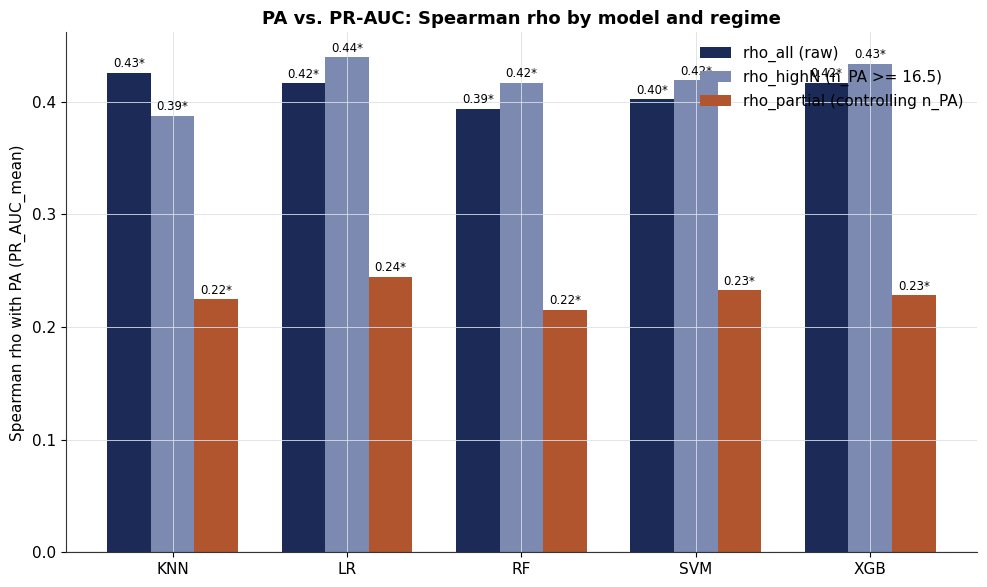

In [12]:
pr_auc_summary = summary[summary["metric"] == "PR_AUC_mean"].set_index("model")
pr_auc_p = summary[summary["metric"] == "PR_AUC_mean"].set_index("model")
models_order = list(MODEL_FILES.keys())

x = np.arange(len(models_order))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars_all = ax.bar(x - width, pr_auc_summary.loc[models_order, "rho_all"], width,
                   label="rho_all (raw)", color=ACCENT)
bars_high = ax.bar(x, pr_auc_summary.loc[models_order, "rho_highN"], width,
                    label="rho_highN (n_PA >= 16.5)", color=ACCENT_LIGHT)
bars_partial = ax.bar(x + width, pr_auc_summary.loc[models_order, "rho_partial"], width,
                       label="rho_partial (controlling n_PA)", color=HIGHLIGHT)

ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models_order, fontsize=11)
ax.set_ylabel("Spearman rho with PA (PR_AUC_mean)", fontsize=11)
ax.set_title("PA vs. PR-AUC: Spearman rho by model and regime", fontsize=13)
ax.legend(frameon=False, loc="upper right")

for bars, col_p in [(bars_all, "p_all"), (bars_high, "p_highN"), (bars_partial, "p_partial")]:
    for bar, (_, row) in zip(bars, pr_auc_summary.loc[models_order].iterrows()):
        sig = "*" if row[col_p] < 0.05 else ""
        ax.annotate(f"{bar.get_height():.2f}{sig}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 4 if bar.get_height() >= 0 else -14),
                    ha="center", fontsize=8.5)

fig.tight_layout()
plt.show()

### 5.2 PA vs. PR_AUC scatter, one panel per model
Color is a **gradient over label identity** (alphabetical order -> colormap), so the same label has the same color in every model's panel -- useful for spotting whether the same labels sit as outliers across models. Circle **area is proportional to n_PA**.

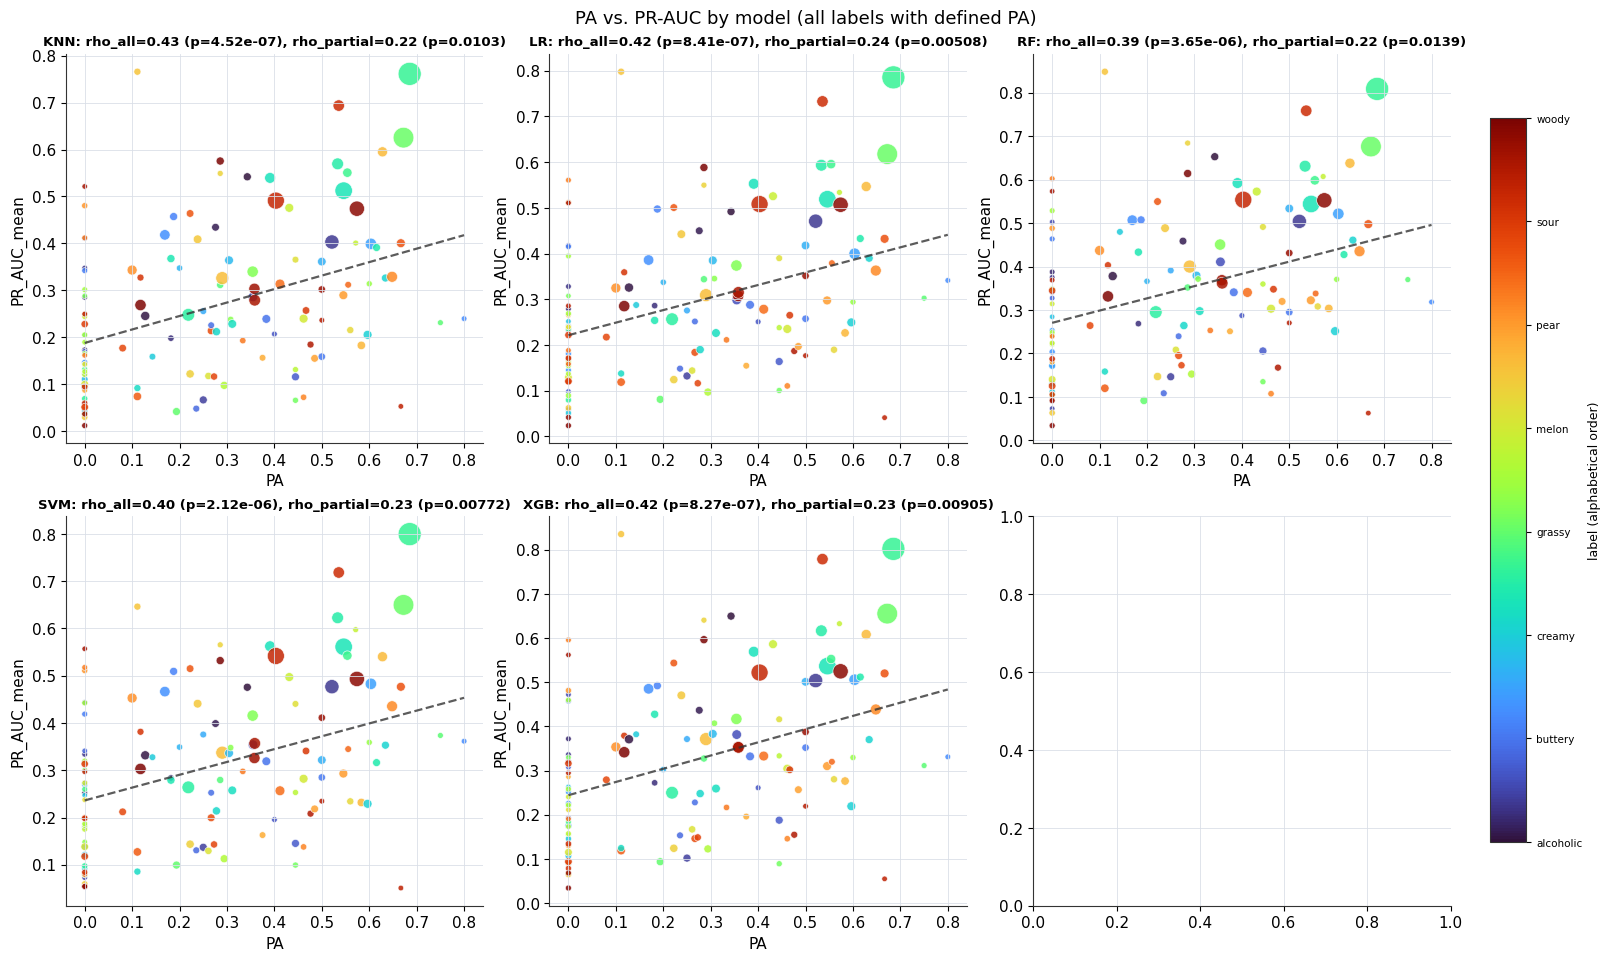

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5), constrained_layout=True)
axes_flat = axes.flat

for ax, model_name in zip(axes_flat, models_order):
    df = merged_by_model[model_name]
    sub = df[["label", "PA", "PR_AUC_mean", "n_molecules"]].dropna()

    ax.scatter(sub["PA"], sub["PR_AUC_mean"],
               s=bubble_size(sub["n_molecules"]),
               color=label_colors(sub["label"]),
               alpha=0.85, edgecolor="white", linewidth=0.5)

    # Linear trend line for visual reference only
    coef = np.polyfit(sub["PA"], sub["PR_AUC_mean"], 1)
    x_line = np.linspace(sub["PA"].min(), sub["PA"].max(), 50)
    ax.plot(x_line, np.polyval(coef, x_line), color="#333333", linewidth=1.6,
            linestyle="--", alpha=0.8)

    row = summary[(summary["model"] == model_name) & (summary["metric"] == "PR_AUC_mean")].iloc[0]
    ax.set_title(f"{model_name}: rho_all={row['rho_all']:.2f} (p={row['p_all']:.3g}), "
                 f"rho_partial={row['rho_partial']:.2f} (p={row['p_partial']:.3g})",
                 fontsize=9.5)
    ax.set_xlabel("PA")
    ax.set_ylabel("PR_AUC_mean")

# hide the unused 6th panel
for ax in axes_flat:
    if not ax.has_data():
        ax.axis("off")

add_label_gradient_colorbar(fig, axes)


# 3. Remove the manual 'y' offset to let constrained_layout place the title
fig.suptitle("PA vs. PR-AUC by model (all labels with defined PA)", fontsize=13)

# 4. Remove fig.tight_layout() since constrained_layout=True handles it better now
plt.show()

### 5.3 All five models on one axis: PR_AUC_mean vs. PA
Each point is one label for one model (five points per label, one per model); color = model, with each model's own linear trend line overlaid so you can compare slopes directly.

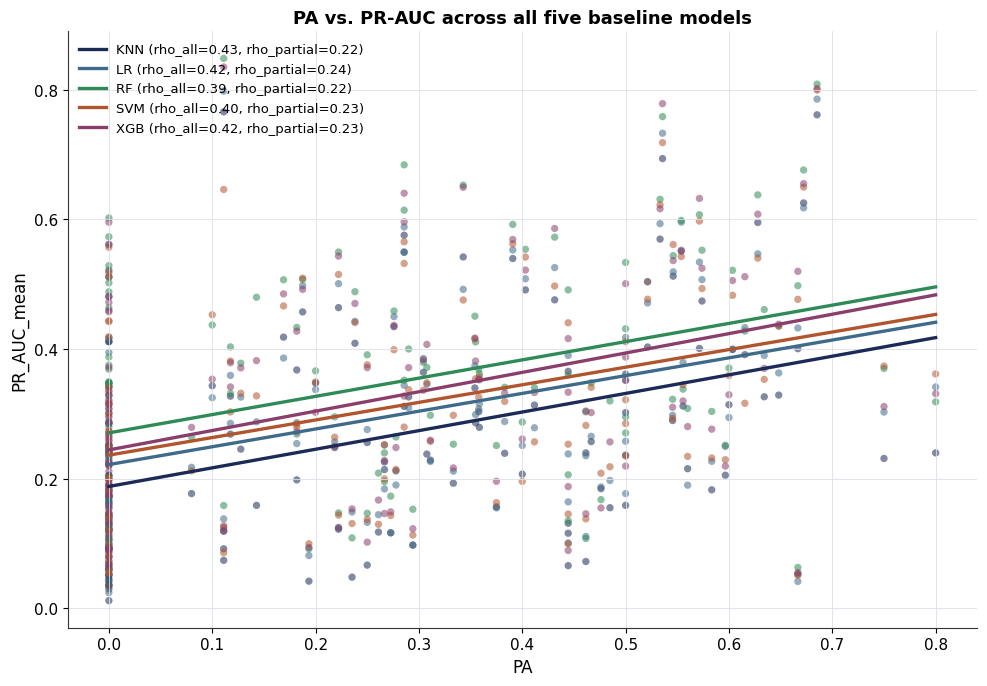

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

for model_name in models_order:
    df = merged_by_model[model_name]
    sub = df[["PA", "PR_AUC_mean"]].dropna()
    ax.scatter(sub["PA"], sub["PR_AUC_mean"], color=MODEL_COLORS[model_name],
               s=28, alpha=0.55, edgecolor="none", label=None)

    coef = np.polyfit(sub["PA"], sub["PR_AUC_mean"], 1)
    x_line = np.linspace(sub["PA"].min(), sub["PA"].max(), 50)
    row = summary[(summary["model"] == model_name) & (summary["metric"] == "PR_AUC_mean")].iloc[0]
    ax.plot(x_line, np.polyval(coef, x_line), color=MODEL_COLORS[model_name],
            linewidth=2.4,
            label=f"{model_name} (rho_all={row['rho_all']:.2f}, rho_partial={row['rho_partial']:.2f})")

ax.set_xlabel("PA", fontsize=12)
ax.set_ylabel("PR_AUC_mean", fontsize=12)
ax.set_title("PA vs. PR-AUC across all five baseline models", fontsize=13)
ax.legend(frameon=False, loc="upper left", fontsize=9.5)
fig.tight_layout()
plt.show()

### 5.4 Same plot, faceted by model (one clean panel each)
The overlay above is useful for slope comparison, but individual panels are easier to read point-by-point -- this repeats 5.3 as a wider, higher-clarity single-metric version with labels for the extreme points.

/tmp/ipykernel_552/1106087062.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


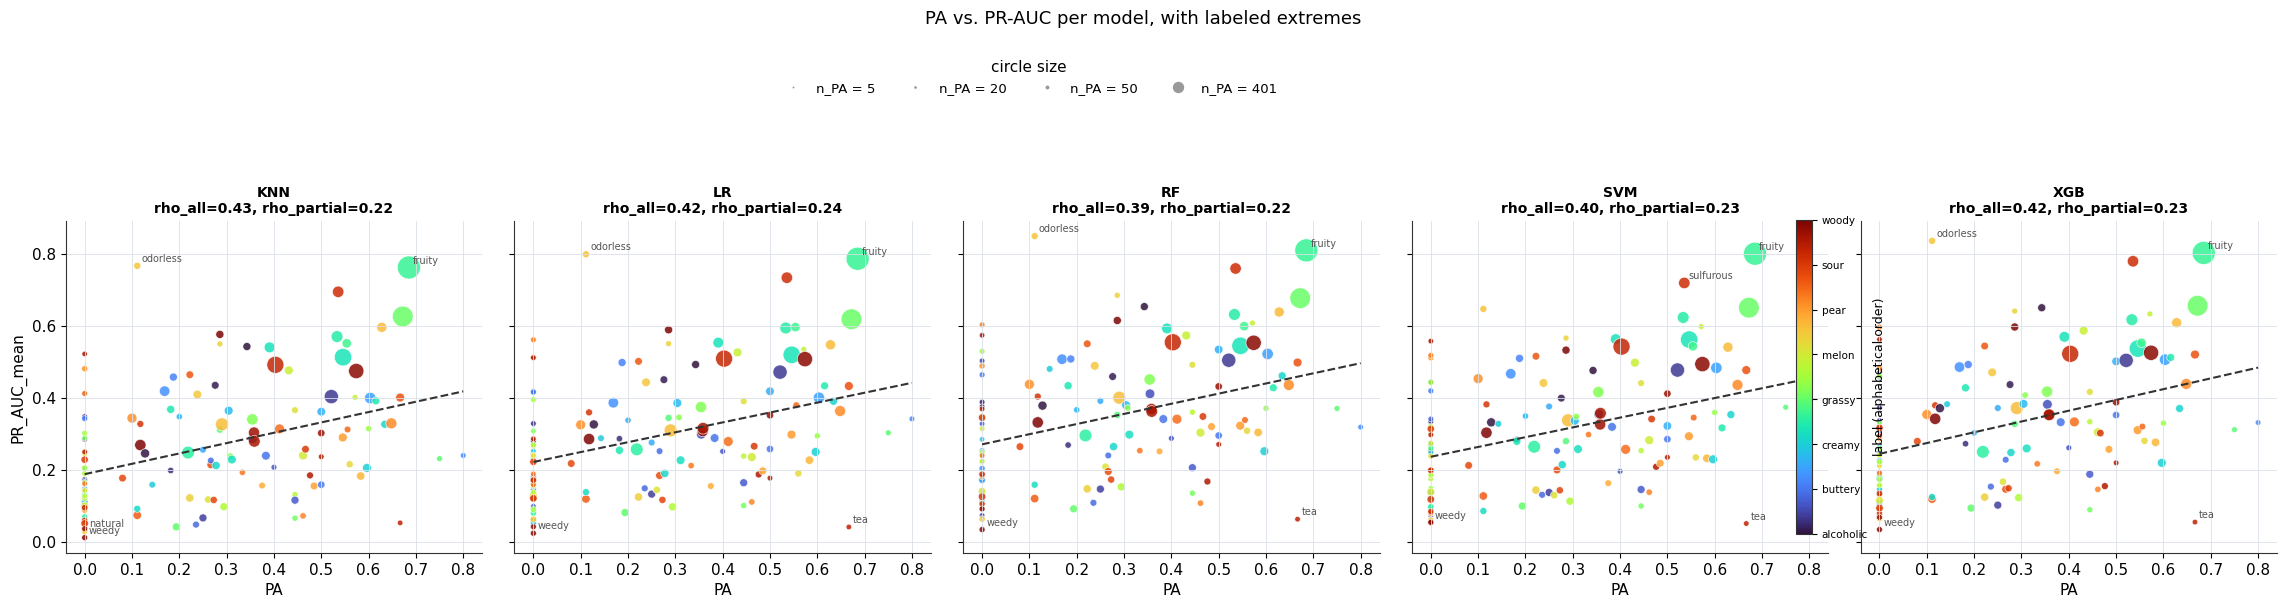

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(23, 4.8), sharey=True)

for ax, model_name in zip(axes, models_order):
    df = merged_by_model[model_name]
    sub = df[["label", "PA", "PR_AUC_mean", "n_molecules"]].dropna()

    ax.scatter(sub["PA"], sub["PR_AUC_mean"],
               s=bubble_size(sub["n_molecules"]),
               color=label_colors(sub["label"]),
               alpha=0.85, edgecolor="white", linewidth=0.5)

    coef = np.polyfit(sub["PA"], sub["PR_AUC_mean"], 1)
    x_line = np.linspace(sub["PA"].min(), sub["PA"].max(), 50)
    ax.plot(x_line, np.polyval(coef, x_line), color="#333333", linewidth=1.5, linestyle="--")

    # Label the top-2 and bottom-2 PR_AUC labels for orientation
    extremes = pd.concat([sub.nlargest(2, "PR_AUC_mean"), sub.nsmallest(2, "PR_AUC_mean")])
    for _, r in extremes.iterrows():
        ax.annotate(r["label"], (r["PA"], r["PR_AUC_mean"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points", color="#555555")

    row = summary[(summary["model"] == model_name) & (summary["metric"] == "PR_AUC_mean")].iloc[0]
    ax.set_title(f"{model_name}\nrho_all={row['rho_all']:.2f}, rho_partial={row['rho_partial']:.2f}",
                 fontsize=10)
    ax.set_xlabel("PA")

axes[0].set_ylabel("PR_AUC_mean")

add_label_gradient_colorbar(fig, axes)

example_n = [5, 20, 50, int(MAX_N_PA_ALL)]
size_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#999999",
           markersize=np.sqrt(bubble_size(n)) / 1.8, label=f"n_PA = {n}")
    for n in example_n
]
fig.legend(handles=size_handles, loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.45, 1.18), fontsize=9.5, title="circle size")

fig.suptitle("PA vs. PR-AUC per model, with labeled extremes", y=1.26, fontsize=13)
fig.tight_layout()
plt.show()

### 5.5 Heatmap: rho_partial for every model x metric combination
A compact summary view -- darker/more saturated = stronger positive partial correlation with PA once n_PA is controlled for.

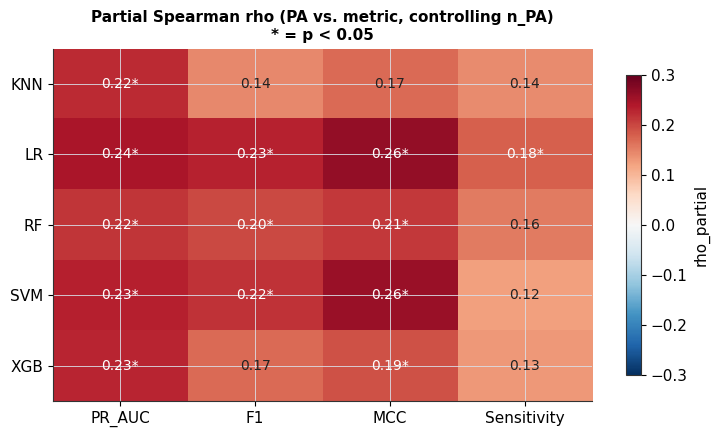

In [11]:
pivot_partial = summary.pivot(index="model", columns="metric", values="rho_partial").loc[models_order, METRICS_TO_TEST]
pivot_p = summary.pivot(index="model", columns="metric", values="p_partial").loc[models_order, METRICS_TO_TEST]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.imshow(pivot_partial.values, cmap="RdBu_r", vmin=-0.3, vmax=0.3, aspect="auto")

ax.set_xticks(range(len(METRICS_TO_TEST)))
ax.set_xticklabels([m.replace("_mean", "") for m in METRICS_TO_TEST])
ax.set_yticks(range(len(models_order)))
ax.set_yticklabels(models_order)

for i in range(pivot_partial.shape[0]):
    for j in range(pivot_partial.shape[1]):
        val = pivot_partial.values[i, j]
        p = pivot_p.values[i, j]
        sig = "*" if p < 0.05 else ""
        ax.text(j, i, f"{val:.2f}{sig}", ha="center", va="center",
                color="white" if abs(val) > 0.18 else "#222222", fontsize=10)

ax.set_title("Partial Spearman rho (PA vs. metric, controlling n_PA)\n* = p < 0.05", fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.85, label="rho_partial")
fig.tight_layout()
plt.show()

### 5.6 High- vs. low-n_PA subsets, PR_AUC only, all models side by side
Boxplots of PR_AUC_mean split by the median n_PA, one pair of boxes per model -- a quick visual check on whether the high-n_PA subset (more reliable PA) also tends to have higher PR-AUC.

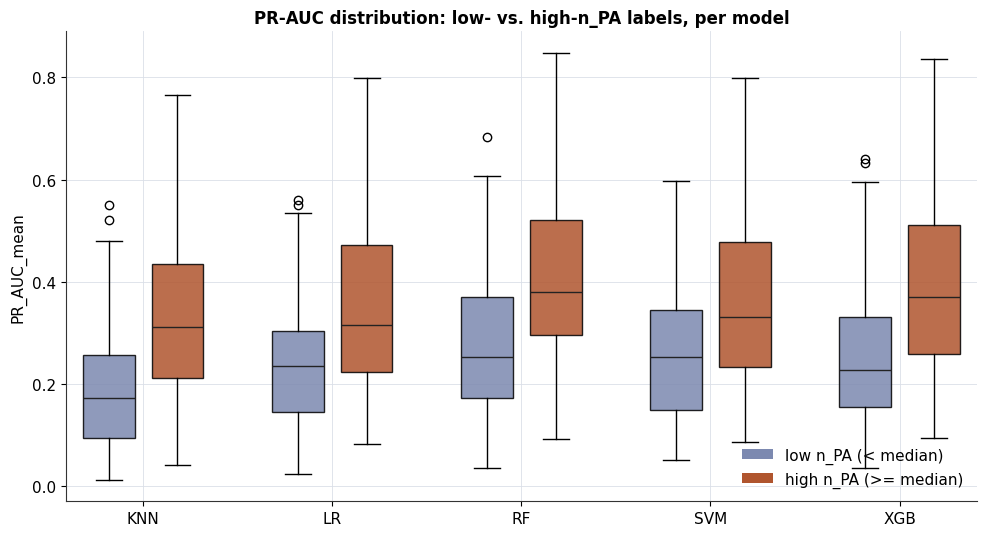

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))

box_data = []
box_positions = []
box_colors = []
tick_positions = []
tick_labels = []

pos = 0
for model_name in models_order:
    df = merged_by_model[model_name]
    median_n_pa = median_n_pa_by_model[model_name]
    low = df.loc[df["n_molecules"] < median_n_pa, "PR_AUC_mean"].dropna()
    high = df.loc[df["n_molecules"] >= median_n_pa, "PR_AUC_mean"].dropna()

    box_data.extend([low, high])
    box_positions.extend([pos, pos + 0.8])
    box_colors.extend([ACCENT_LIGHT, HIGHLIGHT])
    tick_positions.append(pos + 0.4)
    tick_labels.append(model_name)
    pos += 2.2

bp = ax.boxplot(box_data, positions=box_positions, widths=0.6, patch_artist=True,
                 medianprops={"color": "#222222"})
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("PR_AUC_mean")
ax.set_title("PR-AUC distribution: low- vs. high-n_PA labels, per model")

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=ACCENT_LIGHT, label="low n_PA (< median)"),
                   Patch(facecolor=HIGHLIGHT, label="high n_PA (>= median)")]
ax.legend(handles=legend_handles, frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

## Notes

- All five baselines are merged against the **same PA file**
  (`pa_per_label_gs_lw.csv`), so any cross-model differences reflect the
  models' own per-label metric profiles, not a different PA source.
- As with HMCN, expect the **raw** PA-PR_AUC correlation (`rho_all`) to be
  driven substantially by `n_PA`: the **partial** correlation
  (`rho_partial`, controlling for `n_PA`) is the more trustworthy number for
  claims like "PA predicts PR-AUC independent of sample size."
- If a specific model's `rho_partial` stays meaningfully positive while
  others collapse toward zero, that's worth a closer look -- it would mean
  PA carries independent signal for that model's predictions specifically,
  not just as a proxy for how much training/eval data a label had.